### Cluster 2 (2620 companies, 75 bankrupt)
### Strategy: Stacking with Class-Weighted Random Forest & HistGradientBoosting

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold

In [2]:
# Configuration
CLUSTER_ID = 2
INPUT_FILE = f"cluster_{CLUSTER_ID}.csv" 
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = f"cluster{CLUSTER_ID}_stacking.joblib"
RANDOM_STATE = 42

# ==========================================
# 2. Data Loading
# ==========================================
print(f"Loading data for Cluster {CLUSTER_ID}...")
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}")
print(f"Class Distribution:\n{df['Bankrupt?'].value_counts()}")

Loading data for Cluster 2...
Shape: (2620, 98)
Class Distribution:
Bankrupt?
0    2545
1      75
Name: count, dtype: int64


In [3]:
# Load the selected features (ensure consistent features across subgroups as per 3.3.2)
features_to_use = joblib.load(FEATURE_FILE)
print(f"Loaded {len(features_to_use)} selected features.")

X = df[features_to_use]
y = df["Bankrupt?"]

Loaded 40 selected features.


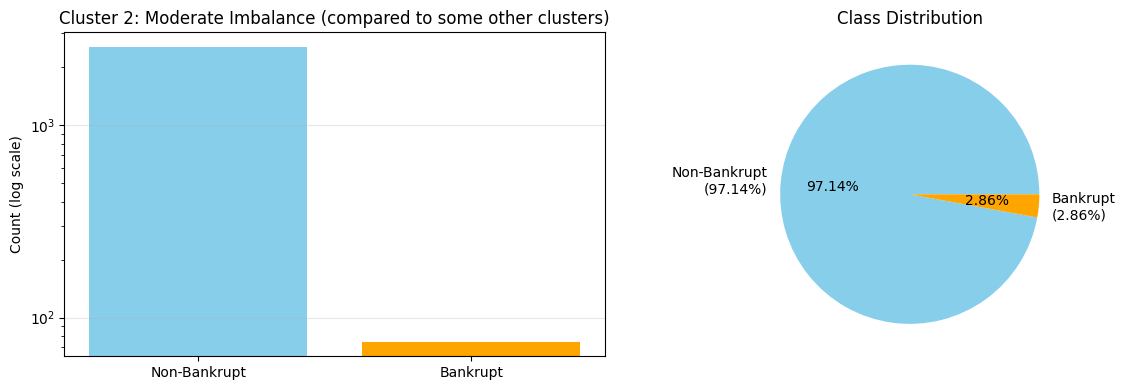

In [4]:
# Get class counts from the dataframe
class_counts = y.value_counts().sort_index()
non_bankrupt_count = class_counts[0]
bankrupt_count = class_counts[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Non-Bankrupt', 'Bankrupt'], [non_bankrupt_count, bankrupt_count], color=['skyblue', 'orange'])
axes[0].set_ylabel('Count (log scale)')
axes[0].set_yscale('log')
axes[0].set_title(f'Cluster {CLUSTER_ID}: Moderate Imbalance (compared to some other clusters)')
axes[0].grid(axis='y', alpha=0.3)

total = non_bankrupt_count + bankrupt_count
axes[1].pie([non_bankrupt_count, bankrupt_count], 
            labels=[f'Non-Bankrupt\n({non_bankrupt_count/total*100:.2f}%)', 
                    f'Bankrupt\n({bankrupt_count/total*100:.2f}%)'], 
            colors=['skyblue', 'orange'], autopct='%1.2f%%')
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_class_distribution.png", dpi=300)
plt.show()

In [5]:
# Model 1: Random Forest
# class_weight='balanced' handles the 2.8% imbalance
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# Model 2: HistGradientBoosting
# Excellent for tabular data, handles imbalance via class_weight
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

# Model 3: Logistic Regression
lr_base = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)


estimators = [
    ('rf', rf),
    ('hgb', hgb),
    ('lr', lr_base)
]

# Stacking Classifier
# Meta-learner: Logistic Regression is standard for stacking
clf_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5,  # 5-fold cross-validation for training meta-model
    n_jobs=-1
)
clf_stack.fit(X, y)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('hgb',
                                HistGradientBoostingClassifier(class_weight='balanced',
                                                               learning_rate=0.05,
                                                               max_iter=200,
                                                               random_state=42)),
                               ('lr',
                                LogisticRegression(class_weight='balanced',
                                                   max_iter=1000,
                                                   random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced'),
                   n_jobs=-1)

In [8]:
# Evaluation
def get_metrics(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    FF, FT, TF, TT = cm.ravel()
    
    # Equation 1 Accuracy: TT / (TF + TT)
    acc_eq1 = TT / (TF + TT) if (TF + TT) > 0 else 0
    
    print(f"{name}")
    print(f"Confusion Matrix: [[{FF}, {FT}], [{TF}, {TT}]]")
    print(f"Eq(1) Accuracy: {acc_eq1:.4f}")
    return FF, FT, TF, TT, acc_eq1

print(f"RESULTS FOR TABLE 3 (Cluster {CLUSTER_ID})")

# A. Base Model Performance
# We use the fitted base models inside the stack
print("\nBase Model Performance (on full train set):")
for name, est in clf_stack.named_estimators_.items():
    y_pred_base = est.predict(X)
    get_metrics(y, y_pred_base, f"Base: {name}")

# B. Stacking Model Performance
print("\nStacking Model Performance (Final):")
y_pred_stack = clf_stack.predict(X)
FF, FT, TF, TT, acc = get_metrics(y, y_pred_stack, "STACKING MODEL")

# Save Model Package
model_package = {
    "cluster_id": CLUSTER_ID,
    "features": features_to_use,
    "model": clf_stack,
    "stats": {"TT": TT, "TF": TF, "N_features": len(features_to_use)}
}

joblib.dump(model_package, OUTPUT_MODEL)

print(f"TT: {TT}, TF: {TF}, N_features: {len(features_to_use)}")

RESULTS FOR TABLE 3 (Cluster 2)

Base Model Performance (on full train set):
Base: rf
Confusion Matrix: [[2514, 31], [0, 75]]
Eq(1) Accuracy: 1.0000
Base: hgb
Confusion Matrix: [[2545, 0], [0, 75]]
Eq(1) Accuracy: 1.0000
Base: lr
Confusion Matrix: [[1679, 866], [35, 40]]
Eq(1) Accuracy: 0.5333

Stacking Model Performance (Final):
STACKING MODEL
Confusion Matrix: [[2313, 232], [0, 75]]
Eq(1) Accuracy: 1.0000
TT: 75, TF: 0, N_features: 40


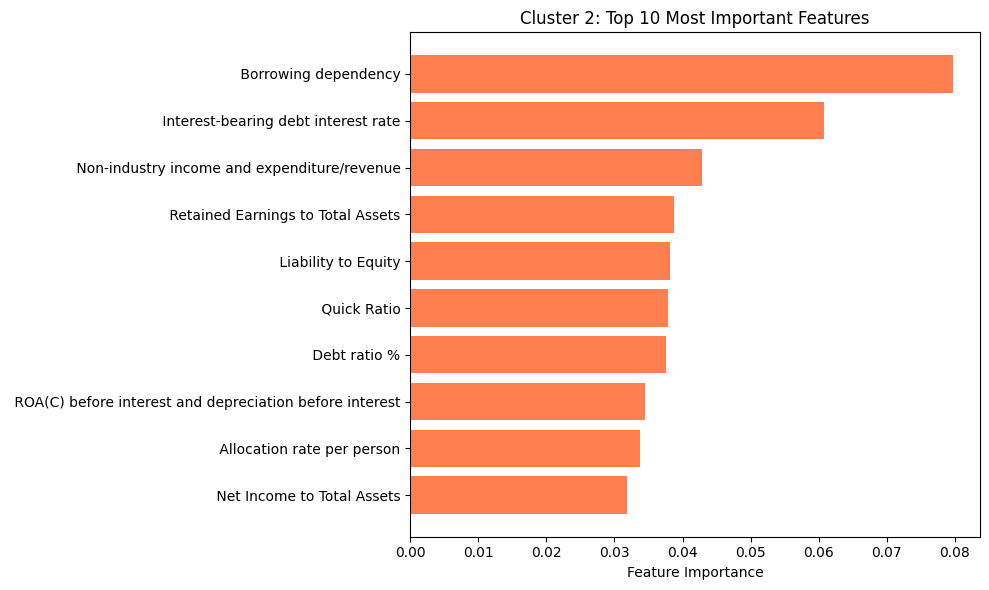

In [7]:
# PLOT 2: Feature Importance from Random Forest (already in your model)
importances = clf_stack.named_estimators_['rf'].feature_importances_
top_10_idx = np.argsort(importances)[-10:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[top_10_idx][::-1], color='coral')
plt.yticks(range(10), [features_to_use[i] for i in top_10_idx][::-1])
plt.xlabel('Feature Importance')
plt.title(f'Cluster {CLUSTER_ID}: Top 10 Most Important Features')
plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_feature_importance.png", dpi=300)
plt.show()